In [12]:
start_time = "2025-11-11T00:00:00"
end_time = "2025-11-16T00:00:00"
out_name = './plots/storm_nov11.png'

In [8]:
from cdasws import CdasWs

# Set list of variable names to load. This can be made to download only what you need.
# Variables not listed here are "support variables" and will be pulled in automatically.
variables = [
   "BX_GSE",
   "BY_GSM",
   "BZ_GSM",
   "Pressure",
   "SYM_H",
]
    
cdas = CdasWs()

# Get the data. If this issues a UserWarning about Nanoseconds, it is harmless
status, data_xarray = cdas.get_data("OMNI_HRO_1MIN", variables, start_time, end_time)

print("Request Status:", status)
print(data_xarray)

Request Status: {'http': {'status_code': 200}, 'cdas': {'status': [], 'message': [], 'warning': [], 'error': []}}
{'Epoch': VarCopy([datetime.datetime(2025, 11, 11, 0, 0),
         datetime.datetime(2025, 11, 11, 0, 1),
         datetime.datetime(2025, 11, 11, 0, 2), ...,
         datetime.datetime(2025, 11, 15, 23, 58),
         datetime.datetime(2025, 11, 15, 23, 59),
         datetime.datetime(2025, 11, 16, 0, 0)], dtype=object), 'BX_GSE': VarCopy([6.63, 6.63, 6.8 , ..., 6.33, 6.38, 6.39], dtype=float32), 'BY_GSM': VarCopy([-0.75, -0.59, -0.37, ...,  0.79,  0.54,  0.02], dtype=float32), 'BZ_GSM': VarCopy([-3.7 , -3.53, -3.23, ..., -0.45, -0.38,  0.31], dtype=float32), 'Pressure': VarCopy([ 1.27,  1.4 ,  1.5 , ...,  1.74,  1.74, 99.99], dtype=float32), 'SYM_H': VarCopy([-20, -21, -21, ..., -37, -37, -37], dtype=int32)}


In [9]:
import numpy as np

omni_epoch = data_xarray['Epoch']
omni_Bx = data_xarray['BX_GSE']
omni_By = data_xarray['BY_GSM']
omni_Bz = data_xarray['BZ_GSM']
omni_dynpres = data_xarray['Pressure']
symh = data_xarray['SYM_H']

fill_value = 9999
omni_Bx[omni_Bx>fill_value] = np.nan
omni_By[omni_By>fill_value] = np.nan
omni_Bz[omni_Bz>fill_value] = np.nan

fill_value = 99
omni_dynpres[omni_dynpres>=fill_value] = np.nan

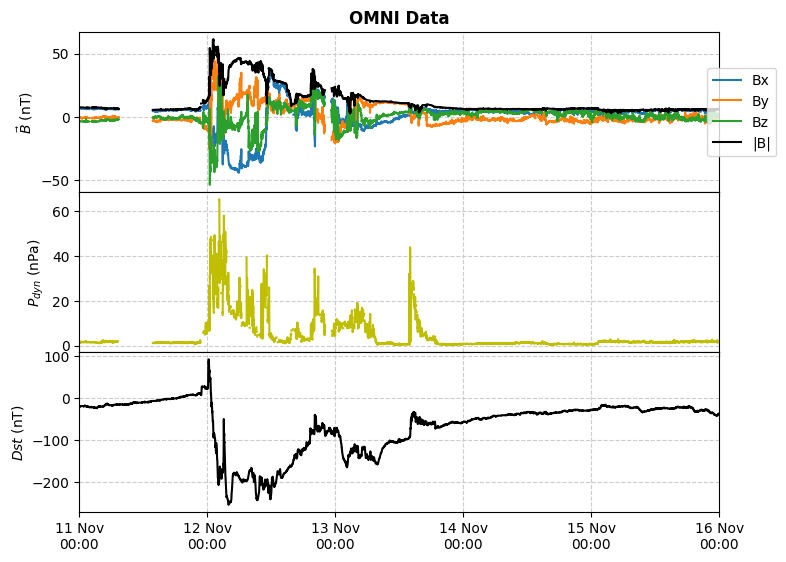

In [10]:

import pylab as plt, numpy as np
from matplotlib import dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0)


axes[0].plot(omni_epoch, omni_Bx, label='Bx')
axes[0].plot(omni_epoch, omni_By, label='By')
axes[0].plot(omni_epoch, omni_Bz, label='Bz')
axes[0].plot(omni_epoch, np.sqrt(omni_Bx**2 + omni_By**2 + omni_Bz**2), label='|B|', color='k')
axes[0].legend(ncol=1, bbox_to_anchor=(1.1, .5), loc='center right')
axes[0].set_ylabel('$\\vec{B}$ (nT)')
axes[1].plot(omni_epoch, omni_dynpres, color='y')
axes[1].set_ylabel('$P_{dyn}$ (nPa)')
axes[2].plot(omni_epoch, symh, color='k')
axes[2].set_ylabel('$Dst$ (nT)')

for ax in axes:
    import dateutil.parser
    ax.grid(linestyle='dashed', color='#ccc')
    ax.set_xlim(data_xarray['Epoch'].min(), dateutil.parser.parse(end_time))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b\n%H:%M'))
#axes[0].axvline(dateutil.parser.parse(target_time), color='r')
axes[0].set_title('OMNI Data', fontweight='bold')
plt.savefig(out_name, dpi=300)